# K-Nearest Neighbors (KNN) — Học từng bước

**Bài toán:** Phân loại học sinh **"Học tốt"** hay **"Cần hỗ trợ"** dựa trên điểm **Toán** và **Văn**.

**Ý tưởng KNN:** *"Hãy nhìn vào những người xung quanh bạn — bạn giống họ"*

> Cho một học sinh mới chưa biết nhãn, KNN tìm **K học sinh gần nhất** trong tập đã biết, rồi **bầu chọn đa số** để quyết định nhãn.


**Mục tiêu:** Tự tay tính khoảng cách, tìm láng giềng, bầu chọn — và hiểu sâu ảnh hưởng của K.

## 1. Dữ liệu

Mỗi học sinh được mô tả bằng 2 thuộc tính:
- **Điểm Toán** ($x_1$): thang 1–10
- **Điểm Văn** ($x_2$): thang 1–10

Nhãn:
- **Lớp 0 (đỏ):** Cần hỗ trợ — điểm thấp ở cả hai môn
- **Lớp 1 (xanh):** Học tốt — điểm cao ở cả hai môn

Hai cụm tách biệt rõ để dễ quan sát, có thêm một điểm mới **★** ở vùng giữa để minh họa KNN.

Tổng số học sinh: 20  |  Lớp 0 (cần hỗ trợ): 10  |  Lớp 1 (học tốt): 10


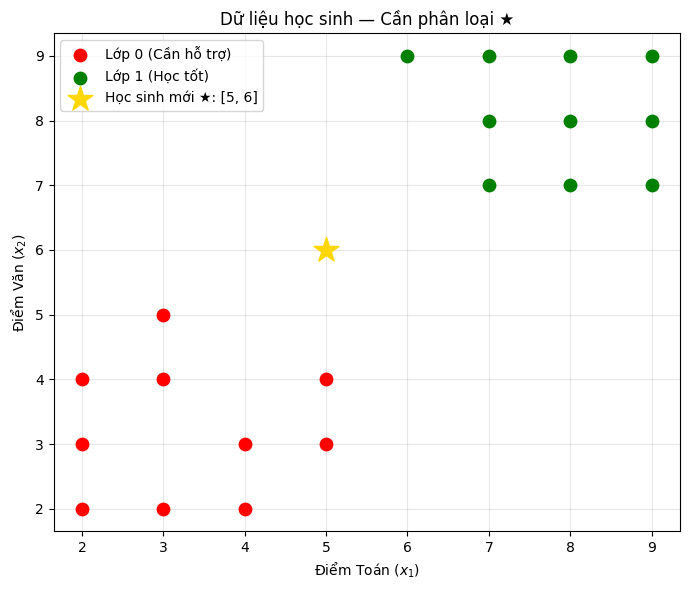

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Lớp 0 (đỏ) - Cần hỗ trợ: điểm thấp
X0 = np.array([
    [2, 3], [3, 2], [4, 3], [2, 4], [3, 5],
    [4, 2], [5, 3], [3, 4], [2, 2], [5, 4]
])

# Lớp 1 (xanh) - Học tốt: điểm cao
X1 = np.array([
    [7, 8], [8, 7], [9, 8], [8, 9], [7, 9],
    [9, 7], [8, 8], [6, 9], [9, 9], [7, 7]
])

X = np.vstack([X0, X1])
y = np.array([0]*10 + [1]*10)

print(f'Tổng số học sinh: {len(y)}  |  Lớp 0 (cần hỗ trợ): {sum(y==0)}  |  Lớp 1 (học tốt): {sum(y==1)}')

new_student = np.array([5, 6])  # Học sinh mới cần phân loại

plt.figure(figsize=(7, 6))
plt.scatter(X0[:,0], X0[:,1], c='red',   label='Lớp 0 (Cần hỗ trợ)', s=80, zorder=3)
plt.scatter(X1[:,0], X1[:,1], c='green', label='Lớp 1 (Học tốt)',    s=80, zorder=3)
plt.scatter(*new_student, c='gold', marker='*', s=350, zorder=5,
            label=f'Học sinh mới ★: {new_student.tolist()}')
plt.xlabel('Điểm Toán ($x_1$)'); plt.ylabel('Điểm Văn ($x_2$)')
plt.title('Dữ liệu học sinh — Cần phân loại ★')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Ý tưởng KNN

**Nguyên lý:** Một học sinh "giống" những người xung quanh.

| Bước | Mô tả |
|---|---|
| **1** | Tính khoảng cách từ điểm cần dự đoán đến **tất cả** điểm trong tập train |
| **2** | Lấy **K điểm gần nhất** (K láng giềng) |
| **3** | **Bầu chọn đa số** — lớp nào xuất hiện nhiều nhất thắng |

**KNN là "Lazy Learner":** Không có giai đoạn huấn luyện thực sự — chỉ lưu toàn bộ dữ liệu. Khi cần dự đoán mới thì mới tính toán.

## 3. Công thức khoảng cách Euclidean

Giữa hai điểm $\mathbf{a} = (a_1, a_2)$ và $\mathbf{b} = (b_1, b_2)$:

$$d(\mathbf{a}, \mathbf{b}) = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2}$$

Tổng quát trong $n$ chiều:

$$d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{i=1}^{n} (a_i - b_i)^2}$$

**Ví dụ tính tay:** Học sinh mới $\mathbf{x} = (5, 6)$, học sinh $A = (5, 4)$:

$$d = \sqrt{(5-5)^2 + (6-4)^2} = \sqrt{0 + 4} = 2.0$$

Học sinh $B = (7, 7)$:

$$d = \sqrt{(5-7)^2 + (6-7)^2} = \sqrt{4 + 1} = \sqrt{5} \approx 2.24$$

In [2]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# Tính khoảng cách từ học sinh mới đến tất cả 20 học sinh
distances  = np.array([euclidean_distance(new_student, X[i]) for i in range(len(X))])
idx_sorted = np.argsort(distances)

print(f'Học sinh mới: x1={new_student[0]}, x2={new_student[1]}')
print(f'\n{"Hạng":>5} {"Tọa độ":>12} {"Khoảng cách":>14} {"Nhãn"}')
print('-' * 58)
for rank, i in enumerate(idx_sorted):
    label = 'Lớp 0 (Cần hỗ trợ)' if y[i] == 0 else 'Lớp 1 (Học tốt)  '
    mark = ''
    if rank == 0: mark = '  <- K=1'
    if rank == 2: mark = '  <- K=3'
    if rank == 4: mark = '  <- K=5'
    print(f'{rank+1:>5} {str(X[i].tolist()):>12} {distances[i]:>14.4f}   {label}{mark}')

Học sinh mới: x1=5, x2=6

 Hạng       Tọa độ    Khoảng cách Nhãn
----------------------------------------------------------
    1       [5, 4]         2.0000   Lớp 0 (Cần hỗ trợ)  <- K=1
    2       [3, 5]         2.2361   Lớp 0 (Cần hỗ trợ)
    3       [7, 7]         2.2361   Lớp 1 (Học tốt)    <- K=3
    4       [3, 4]         2.8284   Lớp 0 (Cần hỗ trợ)
    5       [7, 8]         2.8284   Lớp 1 (Học tốt)    <- K=5
    6       [5, 3]         3.0000   Lớp 0 (Cần hỗ trợ)
    7       [8, 7]         3.1623   Lớp 1 (Học tốt)  
    8       [6, 9]         3.1623   Lớp 1 (Học tốt)  
    9       [4, 3]         3.1623   Lớp 0 (Cần hỗ trợ)
   10       [8, 8]         3.6056   Lớp 1 (Học tốt)  
   11       [7, 9]         3.6056   Lớp 1 (Học tốt)  
   12       [2, 4]         3.6056   Lớp 0 (Cần hỗ trợ)
   13       [9, 7]         4.1231   Lớp 1 (Học tốt)  
   14       [4, 2]         4.1231   Lớp 0 (Cần hỗ trợ)
   15       [8, 9]         4.2426   Lớp 1 (Học tốt)  
   16       [2, 3]         4.2426  

## 4. Bầu chọn với K = 1, 3, 5

Từ bảng khoảng cách trên:

| K | K láng giềng gần nhất | Bầu chọn | Dự đoán |
|---|---|---|---|
| **K=1** | [5,4] → Lớp 0 | 1 vs 0 | **Lớp 0** |
| **K=3** | [5,4] Lớp 0, [3,5] Lớp 0, [7,7] Lớp 1 | 2 vs 1 | **Lớp 0** |
| **K=5** | 3 Lớp 0 + 2 Lớp 1 | 3 vs 2 | **Lớp 0** |

Ba giá trị K đều nhất quán → học sinh mới thuộc **Lớp 0** (Cần hỗ trợ).

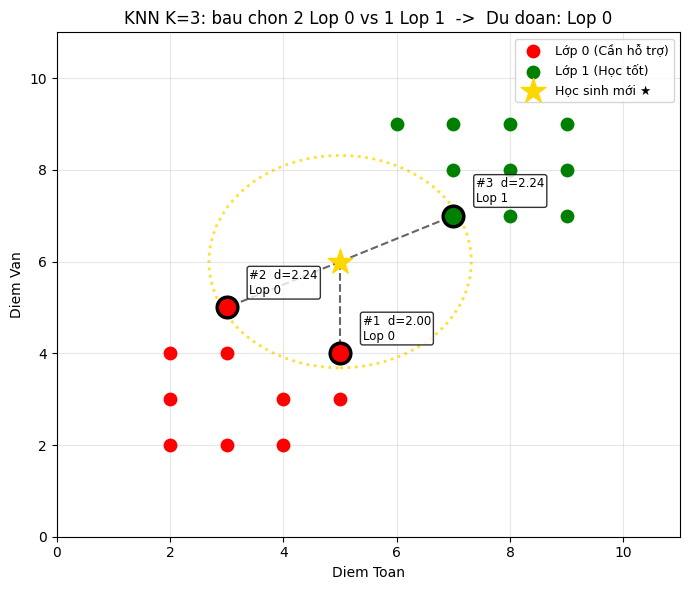

In [3]:
# Visualize KNN với K=3
K      = 3
idx_k3 = idx_sorted[:K]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X0[:,0], X0[:,1], c='red',   label='Lớp 0 (Cần hỗ trợ)', s=80, zorder=3)
ax.scatter(X1[:,0], X1[:,1], c='green', label='Lớp 1 (Học tốt)',    s=80, zorder=3)
ax.scatter(*new_student, c='gold', marker='*', s=350, zorder=5, label='Học sinh mới ★')

for rank, i in enumerate(idx_k3):
    ax.plot([new_student[0], X[i,0]], [new_student[1], X[i,1]],
            'k--', alpha=0.6, linewidth=1.5)
    color = 'red' if y[i] == 0 else 'green'
    ax.scatter(X[i,0], X[i,1], c=color, s=220, zorder=4,
               edgecolors='black', linewidths=2.5)
    ax.annotate(f'#{rank+1}  d={distances[i]:.2f}\nLop {y[i]}',
                xy=(X[i,0], X[i,1]),
                xytext=(X[i,0]+0.4, X[i,1]+0.3),
                fontsize=8.5, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

r = distances[idx_k3[-1]] + 0.08
ax.add_patch(plt.Circle(new_student, r, color='gold', fill=False,
                        linestyle=':', linewidth=2, alpha=0.8))

vote_0 = sum(y[idx_k3] == 0)
vote_1 = sum(y[idx_k3] == 1)
pred   = 0 if vote_0 > vote_1 else 1
ax.set_title(f'KNN K={K}: bau chon {vote_0} Lop 0 vs {vote_1} Lop 1  ->  Du doan: Lop {pred}')
ax.set_xlabel('Diem Toan'); ax.set_ylabel('Diem Van')
ax.set_xlim(0, 11); ax.set_ylim(0, 11)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
# Bảng so sánh kết quả bầu chọn cho các K khác nhau
print('Ket qua bau chon cho hoc sinh moi (5, 6):')
print(f'{"K":>3} | {"Lop 0":>6} | {"Lop 1":>6} | {"Du doan":>10}')
print('-' * 35)

for K in [1, 3, 5, 7, 9, 11]:
    idx_k = idx_sorted[:K]
    v0    = sum(y[idx_k] == 0)
    v1    = sum(y[idx_k] == 1)
    pred  = 'Lop 0' if v0 > v1 else 'Lop 1'
    print(f'{K:>3} | {v0:>6} | {v1:>6} | {pred:>10}')

Ket qua bau chon cho hoc sinh moi (5, 6):
  K |  Lop 0 |  Lop 1 |    Du doan
-----------------------------------
  1 |      1 |      0 |      Lop 0
  3 |      2 |      1 |      Lop 0
  5 |      3 |      2 |      Lop 0
  7 |      4 |      3 |      Lop 0
  9 |      5 |      4 |      Lop 0
 11 |      5 |      6 |      Lop 1


## 5. Ảnh hưởng của K

K kiểm soát **sự phức tạp** của mô hình:

| | K nhỏ | K lớn |
|---|---|---|
| **Ranh giới quyết định** | Gồ ghề, phức tạp | Mịn, đơn giản |
| **Vấn đề** | Nhạy nhiễu → **Overfitting** | Bỏ qua chi tiết → **Underfitting** |
| **Train accuracy** | Cao (K=1 → 100%) | Thấp hơn |

**Quy tắc khởi đầu:** K lẻ (tránh hòa), $K \approx \sqrt{N}$ — sau đó dùng cross-validation để chọn chính xác.

/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aquarter/miniconda3/envs/test/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


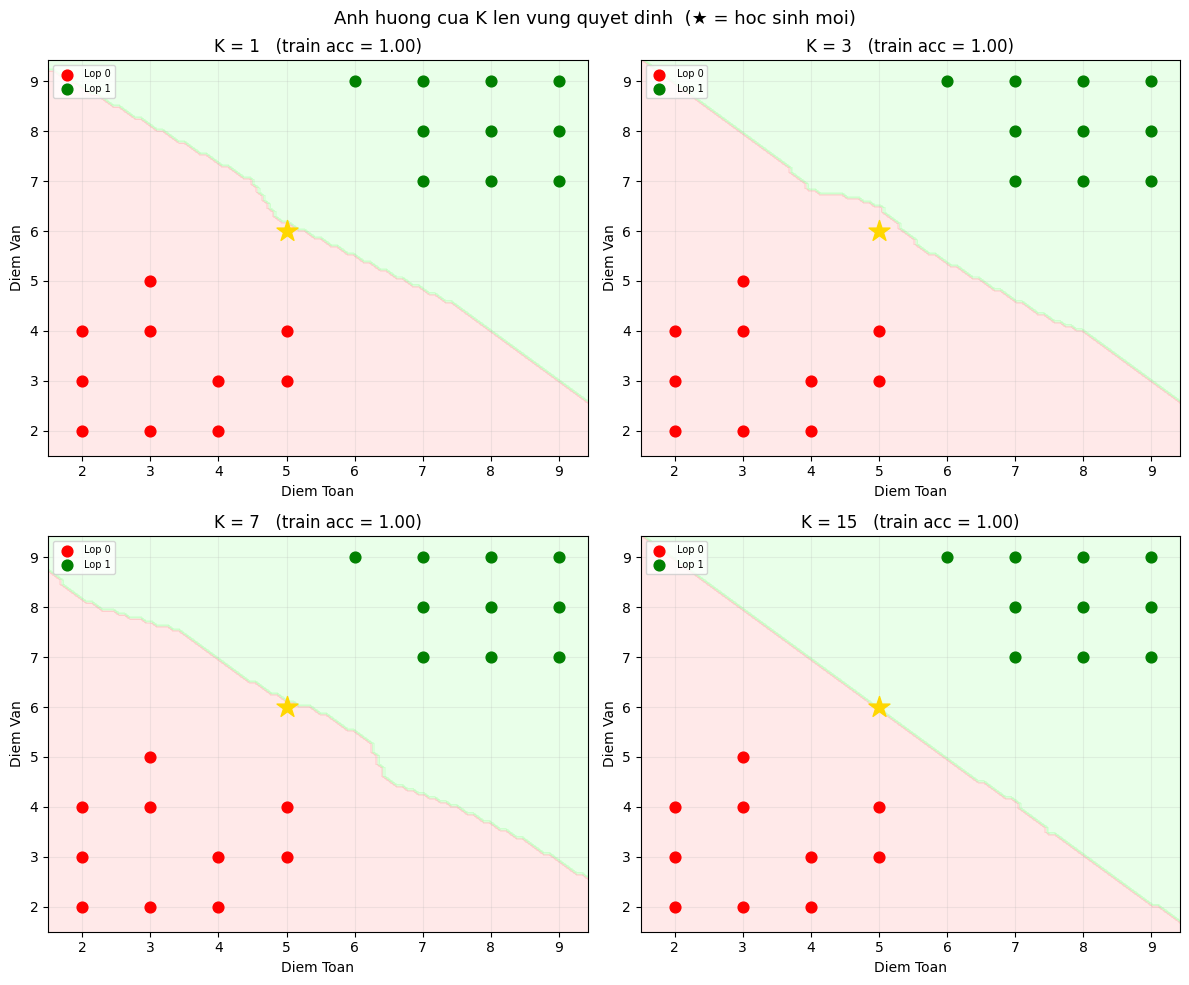

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

def plot_knn_boundary(X, y, k, ax, new_pt=None):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)

    h = 0.08
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25,
                cmap=ListedColormap(['#FFAAAA', '#AAFFAA']))
    ax.scatter(X[y==0,0], X[y==0,1], c='red',   s=60, zorder=3, label='Lop 0')
    ax.scatter(X[y==1,0], X[y==1,1], c='green', s=60, zorder=3, label='Lop 1')
    if new_pt is not None:
        ax.scatter(*new_pt, c='gold', marker='*', s=250, zorder=5)

    acc = clf.score(X, y)
    ax.set_title(f'K = {k}   (train acc = {acc:.2f})')
    ax.set_xlabel('Diem Toan'); ax.set_ylabel('Diem Van')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, k in zip(axes.flat, [1, 3, 7, 15]):
    plot_knn_boundary(X, y, k, ax, new_student)

plt.suptitle('Anh huong cua K len vung quyet dinh  (★ = hoc sinh moi)', fontsize=13)
plt.tight_layout()
plt.savefig('knn_decision_boundary.png', dpi=120, bbox_inches='tight')
plt.show()

### Nhận xét

- **K=1:** Mỗi điểm tạo "bong bóng" riêng, ranh giới rất gồ ghề. Train = 100% nhưng dễ overfit khi có điểm nhiễu.
- **K=3, K=7:** Ranh giới mịn dần, robustness tốt hơn — thường là lựa chọn tốt trong thực tế.
- **K=15:** Ranh giới rất mịn, có thể bỏ qua các chi tiết quan trọng gần biên.

**Kết luận:** Chọn K không quá nhỏ (overfit) cũng không quá lớn (underfit). Dùng cross-validation ở Phần 3.

---
# PHẦN 2: Tầm quan trọng của Chuẩn hóa Dữ liệu

KNN **hoàn toàn phụ thuộc vào khoảng cách** → khi các feature có đơn vị khác nhau, feature có giá trị lớn hơn sẽ **thống trị** tính toán.

**Ví dụ:** Phân loại sức khỏe dựa trên:
- $x_1$: **Huyết áp** (mmHg), giá trị ~80–180
- $x_2$: **Chỉ số BMI**, giá trị ~15–40

Không chuẩn hóa: 1 mmHg huyết áp có "trọng lượng" bằng 1 đơn vị BMI — **sai lầm nghiêm trọng!**

In [6]:
# Dữ liệu sức khỏe: huyết áp (mmHg) và BMI
health_0 = np.array([  # Khỏe mạnh
    [110, 22], [120, 21], [115, 23], [118, 20], [112, 24],
    [108, 22], [116, 21], [122, 23], [114, 20], [119, 22]
])
health_1 = np.array([  # Nguy cơ cao
    [155, 30], [160, 32], [165, 31], [158, 33], [162, 30],
    [150, 31], [168, 34], [153, 32], [170, 30], [157, 33]
])
H  = np.vstack([health_0, health_1])
yH = np.array([0]*10 + [1]*10)  

test_H = np.array([138, 27])  # Điểm mới ở vùng giữa

# Khoảng cách KHÔNG chuẩn hóa
d_raw   = np.array([np.linalg.norm(test_H - H[i]) for i in range(len(H))])
idx_raw = np.argsort(d_raw)[:5]

print('=== KHONG chuan hoa ===')
print(f'Diem moi: Huyet ap={test_H[0]}, BMI={test_H[1]}')
print(f'\n{"Hang":>4} {"HA":>6} {"BMI":>5} {"Khoang cach":>14} {"Nhan"}')
print('-' * 50)
for rank, i in enumerate(idx_raw):
    label = 'Khoe manh  ' if yH[i] == 0 else 'Nguy co cao'
    print(f'{rank+1:>4} {H[i,0]:>6} {H[i,1]:>5} {d_raw[i]:>14.2f}   {label}')

v0 = sum(yH[idx_raw] == 0); v1 = sum(yH[idx_raw] == 1)
print(f'\nK=5: {v0} Khoe manh vs {v1} Nguy co -> Du doan: {"Khoe manh" if v0>v1 else "Nguy co cao"}')
print('\n! Khoang cach bi chi phoi boi huyet ap (80-170) >> BMI (20-34)!')

=== KHONG chuan hoa ===
Diem moi: Huyet ap=138, BMI=27

Hang     HA   BMI    Khoang cach Nhan
--------------------------------------------------
   1    150    31          12.65   Nguy co cao
   2    153    32          15.81   Nguy co cao
   3    122    23          16.49   Khoe manh  
   4    155    30          17.26   Nguy co cao
   5    120    21          18.97   Khoe manh  

K=5: 2 Khoe manh vs 3 Nguy co -> Du doan: Nguy co cao

! Khoang cach bi chi phoi boi huyet ap (80-170) >> BMI (20-34)!


=== SAU khi chuan hoa (StandardScaler) ===

Hang   HA(norm)  BMI(norm)    Khoang cach Nhan
----------------------------------------------------------
   1      0.543      0.848         0.9480   Nguy co cao
   2      0.762      0.651         0.9512   Nguy co cao
   3     -0.683     -0.730         1.0553   Khoe manh  
   4      0.675      1.045         1.1850   Nguy co cao
   5      1.069      0.651         1.2065   Nguy co cao

K=5: 1 Khoe manh vs 4 Nguy co -> Du doan: Nguy co cao


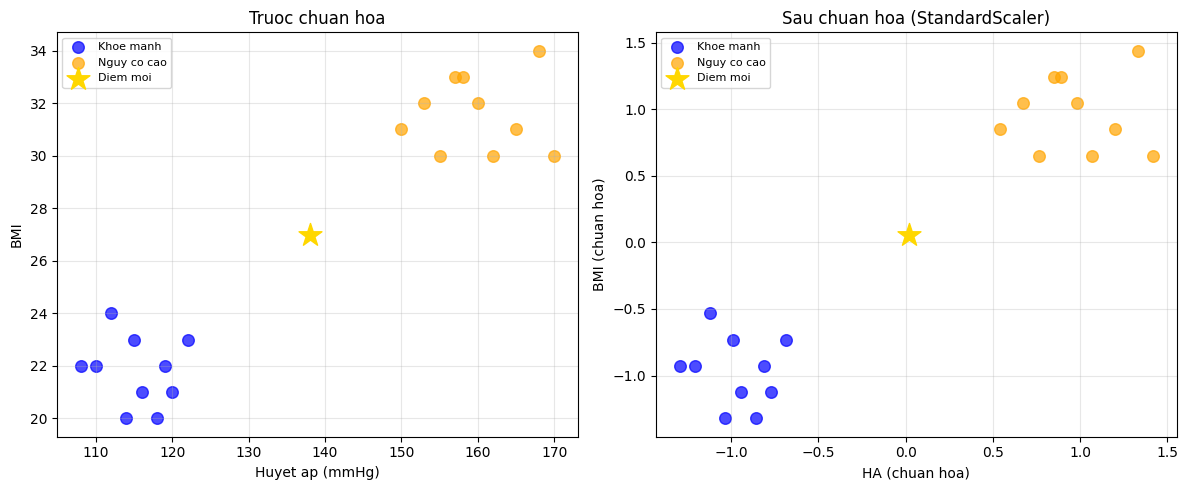

In [7]:
from sklearn.preprocessing import StandardScaler

scaler  = StandardScaler()
H_sc    = scaler.fit_transform(H)
test_sc = scaler.transform([test_H])

d_sc   = np.array([np.linalg.norm(test_sc[0] - H_sc[i]) for i in range(len(H))])
idx_sc = np.argsort(d_sc)[:5]

print('=== SAU khi chuan hoa (StandardScaler) ===')
print(f'\n{"Hang":>4} {"HA(norm)":>10} {"BMI(norm)":>10} {"Khoang cach":>14} {"Nhan"}')
print('-' * 58)
for rank, i in enumerate(idx_sc):
    label = 'Khoe manh  ' if yH[i] == 0 else 'Nguy co cao'
    print(f'{rank+1:>4} {H_sc[i,0]:>10.3f} {H_sc[i,1]:>10.3f} {d_sc[i]:>14.4f}   {label}')

v0s = sum(yH[idx_sc]==0); v1s = sum(yH[idx_sc]==1)
print(f'\nK=5: {v0s} Khoe manh vs {v1s} Nguy co -> Du doan: {"Khoe manh" if v0s>v1s else "Nguy co cao"}')

# Visualize so sánh
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (data, test, title, xl, yl) in zip(axes, [
    (H,    test_H,       'Truoc chuan hoa',              'Huyet ap (mmHg)', 'BMI'),
    (H_sc, test_sc[0],  'Sau chuan hoa (StandardScaler)', 'HA (chuan hoa)', 'BMI (chuan hoa)')
]):
    ax.scatter(data[yH==0,0], data[yH==0,1], c='blue',   s=70, label='Khoe manh',   alpha=0.7)
    ax.scatter(data[yH==1,0], data[yH==1,1], c='orange', s=70, label='Nguy co cao', alpha=0.7)
    ax.scatter(*test, c='gold', marker='*', s=300, zorder=5, label='Diem moi')
    ax.set_title(title); ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
# PHẦN 3: Kiểm chứng bằng scikit-learn + Dữ liệu thực

## Bước 1 — KNeighborsClassifier

`sklearn.neighbors.KNeighborsClassifier` thực hiện đúng quy trình trên nhưng **nhanh hơn nhiều** nhờ cấu trúc dữ liệu KD-tree / Ball-tree — không cần duyệt toàn bộ N mẫu mỗi lần dự đoán.

In [8]:
# Kiểm chứng trên bài toán học sinh
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X, y)

print('=== sklearn KNeighborsClassifier (K=3) ===')
print(f'Accuracy (train): {knn3.score(X, y):.4f}')

pred  = knn3.predict([new_student])[0]
proba = knn3.predict_proba([new_student])[0]
print(f'\nHoc sinh moi {new_student.tolist()}:')
print(f'  Du doan  : Lop {pred} ({"Can ho tro" if pred==0 else "Hoc tot"})')
print(f'  Xac suat : Lop 0 = {proba[0]:.2f}, Lop 1 = {proba[1]:.2f}')
print(f'  (Xac suat = so lang gieng thuoc lop do / K)')
print(f'\n-> Khop voi tinh tay: Lop {pred}')

=== sklearn KNeighborsClassifier (K=3) ===
Accuracy (train): 1.0000

Hoc sinh moi [5, 6]:
  Du doan  : Lop 0 (Can ho tro)
  Xac suat : Lop 0 = 0.67, Lop 1 = 0.33
  (Xac suat = so lang gieng thuoc lop do / K)

-> Khop voi tinh tay: Lop 0


## Bước 2 — Tìm K tối ưu bằng Cross-validation

Dùng **k-fold cross-validation** để đánh giá K nào tốt nhất trên dữ liệu **chưa thấy** — tránh chọn K dựa trên train set (sẽ luôn chọn K=1 vì K=1 cho train=100%).

**5-fold CV:** Chia tập thành 5 phần, lần lượt dùng 4 phần train + 1 phần validate, lấy trung bình 5 kết quả.

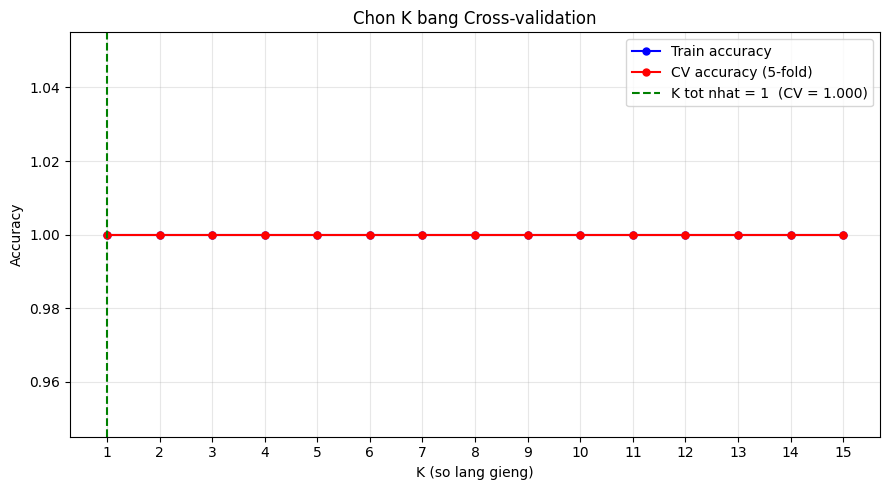

K tot nhat theo 5-fold CV: K = 1
  Train accuracy : 1.0000
  CV accuracy    : 1.0000


In [9]:
from sklearn.model_selection import cross_val_score

k_range      = range(1, 16)
train_scores = []
cv_scores    = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    cv    = cross_val_score(knn_k, X, y, cv=5, scoring='accuracy')
    cv_scores.append(cv.mean())
    knn_k.fit(X, y)
    train_scores.append(knn_k.score(X, y))

best_k = list(k_range)[np.argmax(cv_scores)]

plt.figure(figsize=(9, 5))
plt.plot(k_range, train_scores, 'b-o', label='Train accuracy', markersize=5)
plt.plot(k_range, cv_scores,    'r-o', label='CV accuracy (5-fold)', markersize=5)
plt.axvline(x=best_k, color='green', linestyle='--',
            label=f'K tot nhat = {best_k}  (CV = {max(cv_scores):.3f})')
plt.xlabel('K (so lang gieng)'); plt.ylabel('Accuracy')
plt.title('Chon K bang Cross-validation')
plt.legend(); plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout(); plt.show()

print(f'K tot nhat theo 5-fold CV: K = {best_k}')
print(f'  Train accuracy : {train_scores[best_k-1]:.4f}')
print(f'  CV accuracy    : {cv_scores[best_k-1]:.4f}')

## Bước 3 — Dữ liệu thực: Iris (3 lớp)

Bộ dữ liệu **Iris**: 150 mẫu hoa, 4 thuộc tính số, **3 lớp**.

KNN xử lý multi-class tự nhiên: lớp nào có nhiều phiếu nhất trong K láng giềng thắng.

**Lưu ý:** Chuẩn hóa dữ liệu trước khi dùng KNN — 4 thuộc tính có đơn vị khác nhau.

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

iris = load_iris()
Xi, yi = iris.data, iris.target

print(f'So mau       : {Xi.shape[0]}')
print(f'So thuoc tinh: {Xi.shape[1]}')
print(f'Cac lop      : {iris.target_names}')
for c, name in enumerate(iris.target_names):
    print(f'  {name}: {sum(yi==c)} mau')

# Chia train/test + chuẩn hóa
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    Xi, yi, test_size=0.2, stratify=yi, random_state=42
)

sc_iris = StandardScaler()
Xi_tr_s = sc_iris.fit_transform(Xi_tr)
Xi_te_s = sc_iris.transform(Xi_te)

knn_iris = KNeighborsClassifier(n_neighbors=5)
knn_iris.fit(Xi_tr_s, yi_tr)

print(f'\nIris - KNN K=5 (co chuan hoa):')
print(f'  Train accuracy: {knn_iris.score(Xi_tr_s, yi_tr):.4f}')
print(f'  Test  accuracy: {knn_iris.score(Xi_te_s, yi_te):.4f}')
print()
print(classification_report(yi_te, knn_iris.predict(Xi_te_s),
                             target_names=iris.target_names))

So mau       : 150
So thuoc tinh: 4
Cac lop      : ['setosa' 'versicolor' 'virginica']
  setosa: 50 mau
  versicolor: 50 mau
  virginica: 50 mau

Iris - KNN K=5 (co chuan hoa):
  Train accuracy: 0.9750
  Test  accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



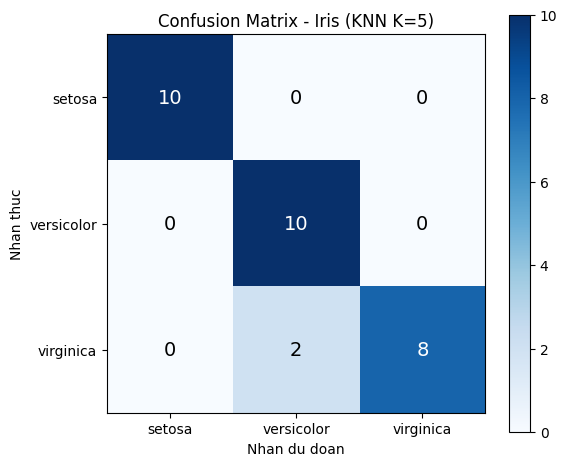

In [11]:
# Confusion matrix
cm = confusion_matrix(yi_te, knn_iris.predict(Xi_te_s))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)
ticks = range(len(iris.target_names))
ax.set_xticks(ticks); ax.set_yticks(ticks)
ax.set_xticklabels(iris.target_names)
ax.set_yticklabels(iris.target_names)
for i in ticks:
    for j in ticks:
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=14,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title('Confusion Matrix - Iris (KNN K=5)')
ax.set_ylabel('Nhan thuc'); ax.set_xlabel('Nhan du doan')
plt.tight_layout()
plt.savefig('knn_iris_confusion.png', dpi=120)
plt.show()

---
## Tổng kết toàn bộ notebook

| Phần | Nội dung | Kỹ thuật chính | Điều cần nhớ |
|---|---|---|---|
| **1** | Phân loại học sinh 2D | Tính khoảng cách tay, bầu chọn | K nhỏ = overfit, K lớn = underfit |
| **2** | Vấn đề scale khác nhau | StandardScaler | **Bắt buộc** chuẩn hóa với KNN |
| **3** | Iris 3 lớp | sklearn, CV, confusion matrix | Cross-validation để chọn K tối ưu |

**Ưu điểm KNN:**
- Đơn giản, không giả định phân phối dữ liệu
- Tự nhiên với multi-class
- Ranh giới quyết định phi tuyến

**Nhược điểm KNN:**
- Chậm khi dự đoán: tính khoảng cách đến toàn bộ N mẫu
- Tốn bộ nhớ: lưu toàn bộ tập train
- Nhạy cảm với scale → phải chuẩn hóa
- Kém hiệu quả khi dữ liệu nhiều chiều (*curse of dimensionality*)

**Ba câu hỏi tự kiểm tra:**
1. Tại sao K=1 gần như luôn cho train accuracy = 100%?
2. Khi nào **bắt buộc** phải chuẩn hóa dữ liệu trước khi dùng KNN?
3. KNN có phù hợp khi tập dữ liệu có 1 triệu mẫu không? Tại sao?